In [1]:
from llrf_app.app import LLRFApp
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import signal

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

In [2]:
def calc_ps(wfm, title='', fullscale=32767, fs_mhz=115):
    fsdb = 20 * np.log10(fullscale / np.sqrt(2))
    f, pxx = signal.periodogram(
        wfm, fs_mhz, 'flattop', scaling='spectrum')
    psd_dbfs = 10 * np.log10(pxx) - fsdb
    return f, psd_dbfs

def plot_ps(f, psd_dbfs, title='', annotate=False):
    fig, ax = plt.subplots()
    ax.set_xlabel('Freq [MHz]')
    ax.set_ylabel('Mag [dBFS]')
    ax.set_ylim(-120, 0)
    ax.set_title(title)
    if len(psd_dbfs.shape) == 1:
        ax.plot(f, psd_dbfs)
        if annotate:
            idx = np.argmax(psd_dbfs)
            pwr = psd_dbfs[idx]
            ax.annotate(
                f'{f[idx]:5.3f}  MHz\n {pwr:5.3f} dBFS',
                xy=(f[idx], pwr), xytext=(1, -20),
                arrowprops=dict(shrink=0.05))
    elif len(psd_dbfs.shape) == 2:   # plot psd array
        for ix, p in enumerate(psd_dbfs):
            ax.plot(f, p, label='adc' + str(ix))
        ax.legend()

In [3]:
llrf = LLRFApp(addr='192.168.19.42:803', conf='LEMP')
llrf.write_reg('amp_setpoint', 30000)

In [4]:
adc_wfm = llrf.read_adc_bufs()

In [5]:
df = pd.DataFrame(adc_wfm.T, columns=[f'adc{n}' for n in range(8)])
df['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.dsp_clk_cycle
df.set_index('Time [ns]')

,adc0,adc1,adc2,adc3,adc4,adc5,adc6,adc7
Time [ns],,,,,,,,
0.0,1904,-24,-226,-199,-166,-248,-193,-158
8.4,1594,-21,-227,-197,-163,-249,-197,-158
16.8,-1462,-21,-227,-194,-165,-250,-192,-164
25.2,-2492,-24,-226,-200,-170,-249,-194,-155
33.6,82,-19,-225,-195,-165,-246,-190,-156
...,...,...,...,...,...,...,...,...
34364.4,-2497,-23,-224,-193,-166,-247,-196,-159
34372.8,79,-24,-224,-192,-169,-251,-196,-160
34381.2,2280,-24,-230,-194,-167,-249,-200,-158


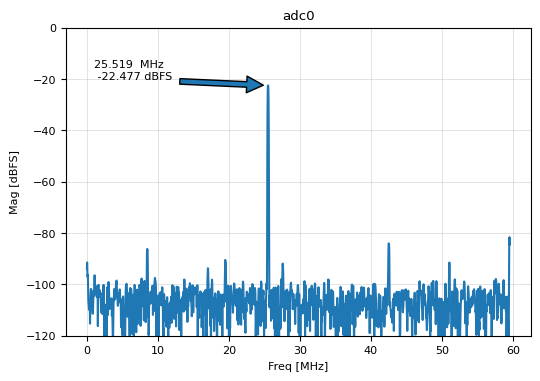

In [6]:
f, psd_dbfs = calc_ps(df['adc0'], fs_mhz=1e3/llrf.dsp_clk_cycle)
plot_ps(f, psd_dbfs, title='adc0', annotate=True)

In [7]:
dac_wfm = llrf.read_dac_bufs()
df_dac = pd.DataFrame(dac_wfm.T, columns=[f'dac{n}' for n in range(2)])
df_dac['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.dsp_clk_cycle
df_dac.set_index('Time [ns]')

,dac0,dac1
Time [ns],,
0.0,6786,6786
8.4,10697,10697
16.8,-2026,-2026
25.2,-11599,-11599
33.6,-3137,-3137
...,...,...
34364.4,-11599,-11599
34372.8,-3137,-3137
34381.2,10203,10203


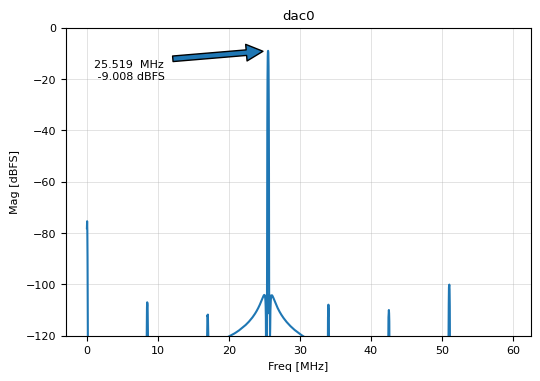

In [8]:
f, psd_dbfs = calc_ps(df_dac['dac0'], fs_mhz=1e3/llrf.dsp_clk_cycle)
plot_ps(f, psd_dbfs, title='dac0', annotate=True)